# Forward PINN for Darcy Flow Below a Reservoir

Goal: build a **forward Physics-Informed Neural Network** for the hydraulic head field `h(x, y)`.

Important distinction:

- The Excel files are useful for **visualizing the problem** and later checking your result.
- The forward PINN loss should use **only the PDE and boundary conditions**, not the measured/generated head values.

This notebook is intentionally written as a scaffold. Some PyTorch pieces are left as `TODO` so you can implement the model yourself.


# 0. Imports

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import random


## set the same random seed for getting same reults in each running
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

## use GPU to train or mps
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# 1. Plot data

The filename pattern is:

```text
h1_h2_hd.xlsx
```

where:

- `h1` is the reservoir head,
- `h2` is the downstream catchment head,
- `hd` is the embedded wall depth.

For a forward PINN, we do **not** train on `FINIT`; here we only inspect it so we understand the geometry and have something to compare with after training.

We choose to base ourselves on the dataset
20_5_25.xlsx


Text(0.5, 1.0, 'Scatter Plot of Water Dam Data')

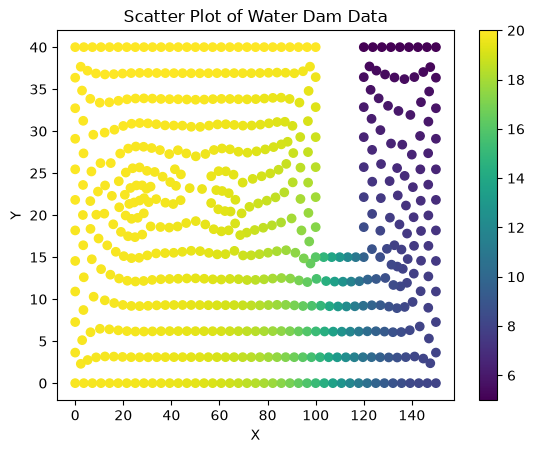

In [3]:
numericldata = pd.read_excel('/Users/hervesv/Documents/CloudDrive/Fac/M1/RWTH_ML/Dam Flow/heads/20_5_25.xlsx',header=0)
X = numericldata['X'].to_numpy()
Y = numericldata['Y'].to_numpy()
h = numericldata['FINIT'].to_numpy()

fig, ax = plt.subplots()
    
scatter = ax.scatter(X, Y, c=h, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot of Water Dam Data')

### Make it into a continous map of h values

In [22]:
# Geometry of problem
h1 = 20
h2 = 5
hd = 25

L = 150

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = L   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - hd    # bottom of dam

def interpolate_head(X, Y, h, 
                     grid_res=(300, 100),
                     domain_bounds=(x_left, x_right, y_bot, y_top),
                     dam_bounds=(x_dleft, x_dright, y_dbot, y_top),
                     method="linear"):
    
    x_min, x_max, y_min, y_max = domain_bounds
    num_x, num_y = grid_res

    # Generate regular 2D grid
    xi = np.linspace(x_min, x_max, num_x)
    yi = np.linspace(y_min, y_max, num_y)
    grid_x, grid_y = np.meshgrid(xi, yi)

    # Interpolate scattered points
    grid_h = griddata((X,Y), h, (grid_x, grid_y), method=method)

    # Mask out dam region
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    # Replace all h values within the dam area with nan
    grid_h[dam_mask] = np.nan

    return grid_x, grid_y, grid_h


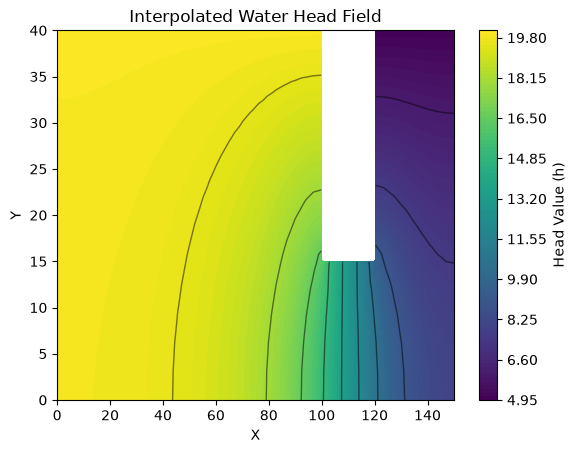

In [23]:
grid_X, grid_Y, grid_h = interpolate_head(X, Y, h)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X, grid_Y, grid_h, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(grid_X, grid_Y, grid_h, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field')
plt.show()

# 2. Draw boundaries and sample collocation and boundary points

Collocation points and boundary condition points. We have three types of boundaries:
1. Boundaries where the value of $h$ is fixed to either $h_1$ or $h_2$
2. Boundaries where $v_x = 0$
3. Boundaries where $v_y = 0$

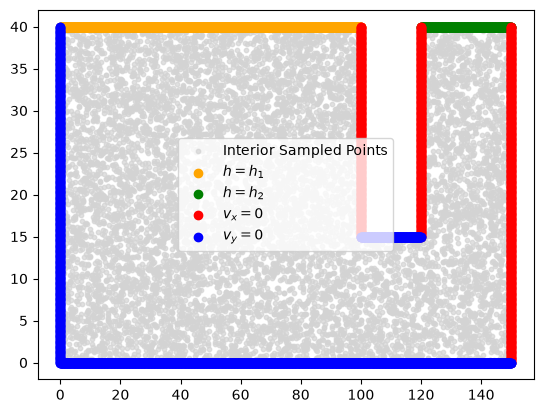

In [47]:
def sample_boundaries(n_density):
    x1 = np.linspace(x_left, x_dleft, n_density * (x_dleft-x_left))
    y1 = np.ones(n_density * (x_dleft-x_left)) * y_top
    h1 = np.column_stack([x1, y1])

    x2 = np.linspace(x_dright, x_right, n_density*(x_right-x_dright))
    y2 = np.ones(n_density*(x_right-x_dright)) * y_top
    h2 = np.column_stack([x2, y2])


    x3 = np.ones(n_density*(y_top-y_dbot)) * x_dleft
    y3 = np.linspace(y_dbot, y_top, n_density*(y_top-y_dbot))

    x4 = np.ones(n_density*(y_top-y_dbot)) * x_dright
    y4 = np.linspace(y_dbot, y_top, n_density*(y_top-y_dbot))

    x7 = np.ones(n_density*(y_top)) * x_right
    y7 = np.linspace(0, y_top, n_density*(y_top))
    vx0 = np.column_stack([
        np.concatenate([x3, x4, x7]),
        np.concatenate([y3, y4, y7])
    ])

    y5 = np.ones(n_density*(x_dright-x_dleft)) * y_dbot
    x5 = np.linspace(x_dleft, x_dright, n_density*(x_dright-x_dleft))

    y6 = np.zeros(n_density*(x_right))
    x6 = np.linspace(0, x_right, n_density*(x_right))

    x8 = np.ones(n_density*(y_top)) * x_left
    y8 = np.linspace(0, y_top, n_density*(y_top))
    vy0 = np.column_stack([
        np.concatenate([x5, x6, x8]),
        np.concatenate([y5, y6, y8])
    ])

    return {
        "h1": h1,
        "h2": h2,
        "vx0": vx0,
        "vy0": vy0,
    }

def sample_interior_points(num_points=1000):
    sampled_x = []
    sampled_y = []
    
    while len(sampled_x) < num_points:
        # 1. Generate a random candidate point inside the global bounding box
        x_candidate = np.random.uniform(x_left, x_right)
        y_candidate = np.random.uniform(y_bot, y_top)
        
        # 2. Check if the point falls inside the forbidden dam cutout zone
        is_inside_dam = (x_dleft <= x_candidate <= x_dright) and (y_dbot <= y_candidate <= y_top)
        
        # 3. Only keep the point if it is NOT inside the dam
        if not is_inside_dam:
            sampled_x.append(x_candidate)
            sampled_y.append(y_candidate)
            
    return np.array(sampled_x).reshape(-1, 1), np.array(sampled_y).reshape(-1, 1)

# Sample boundary points
bc_density = 10
bc = sample_boundaries(bc_density)

# Sample interior points
n_points = 10000
x_internal, y_internal = sample_interior_points(n_points)

h1_color = "orange"
h2_color = "green"
vx0_color = "red"
vy0_color = "blue"


plt.scatter(x_internal, y_internal, color='lightgray', s=10, label='Interior Sampled Points', alpha=0.7)

x_bc_h1, y_bc_h1 = bc['h1'][:, 0].reshape(-1, 1), bc['h1'][:, 1].reshape(-1, 1)
x_bc_h2, y_bc_h2 = bc['h2'][:, 0].reshape(-1, 1), bc['h2'][:, 1].reshape(-1, 1)
x_bc_vx0, y_bc_vx0 = bc["vx0"][:, 0].reshape(-1, 1), bc["vx0"][:, 1].reshape(-1, 1)
x_bc_vy0, y_bc_vy0 = bc["vy0"][:, 0].reshape(-1, 1), bc["vy0"][:, 1].reshape(-1, 1)

#plt.scatter(bc['h1'][:, 0], bc['h1'][:, 1], color=h1_color, label="$h=h_1$")
#plt.scatter(bc['h2'][:, 0], bc['h2'][:, 1], color=h2_color, label="$h=h_2$")
#plt.scatter(bc["vx0"][:, 0], bc["vx0"][:, 1], color=vx0_color, label="$v_x=0$")
#plt.scatter(bc["vy0"][:, 0], bc["vy0"][:, 1], color=vy0_color, label="$v_y=0$")
#plt.legend()

plt.scatter(x_bc_h1, y_bc_h1, color=h1_color, label="$h=h_1$")
plt.scatter(x_bc_h2, y_bc_h2, color=h2_color, label="$h=h_2$")
plt.scatter(x_bc_vx0, y_bc_vx0, color=vx0_color, label="$v_x=0$")
plt.scatter(x_bc_vy0, y_bc_vy0, color=vy0_color, label="$v_y=0$")
plt.legend()

plt.show()



## 3. Nondimensionalize the Governing Equation

The dimensional PDE is Laplace's equation:

$$
\Delta h = \frac{\partial^2 h}{\partial x^2} + \frac{\partial^2 h}{\partial y^2} = 0.
$$

Choose one length scale, for example the total horizontal length:

$$
L = 150\;\text{m}.
$$

Define dimensionless coordinates and head:

$$
\hat{x}=\frac{x}{L}, \qquad \hat{y}=\frac{y}{L}, \qquad
H = \frac{h-h_2}{h_1-h_2}.
$$

Then:

$$
h = h_2 + (h_1-h_2)H.
$$

Because `h2` and `(h1-h2)` are constants, the PDE becomes:

$$
\frac{\partial^2 H}{\partial \hat{x}^2} +
\frac{\partial^2 H}{\partial \hat{y}^2}=0.
$$

Boundary heads become simple:

$$
H=1 \quad \text{on the reservoir boundary},
$$

$$
H=0 \quad \text{on the downstream catchment boundary}.
$$

Impermeable boundaries satisfy no-flow, so the normal derivative is zero:

$$
\nabla H \cdot n = 0.
$$


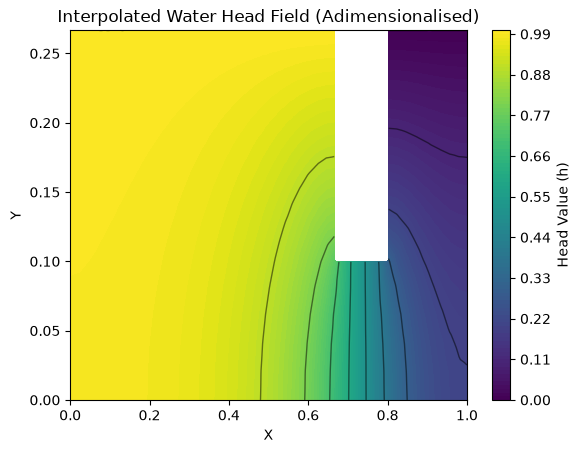

In [27]:
def to_hat_xy(xy):
    """Convert dimensional coordinates [m] to nondimensional coordinates."""
    return xy / L

def to_hat_head(h):
    return (h-h2)/(h1-h2)

def from_hat_head(H):
    """Convert nondimensional head H back to dimensional head h [m]."""
    return h2 + (h1 - h2) * H

grid_X_hat, grid_Y_hat, grid_h_hat = to_hat_xy(grid_X), to_hat_xy(grid_Y), to_hat_head(grid_h)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X_hat, grid_Y_hat, grid_h_hat, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(grid_X_hat, grid_Y_hat, grid_h_hat, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field (Adimensionalised)')
plt.show()

# 4. Define NN model

In [37]:
class MLP(nn.Module):
    # arch = [inputs] + [hidden neurons]*number + [outputs]
    def __init__(self, arch, act):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(arch) - 1):
            layers.append(nn.Linear(arch[i], arch[i + 1]))
            if i < len(arch) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        out = self.model(inputs)
        return out

# 5. Define PINN Loss functions

Our model receives non-dimensional coordinates and predicts non-dimensional head:

$$
(\hat{x}, \hat{y}) \mapsto H_\theta(\hat{x}, \hat{y}).
$$

We have two types of loss: boundary condition loss and PDE loss. Each boundary type has its own loss:





In [48]:
# when head must have a specfic numerical value at boundary
def loss_bc_value(model, x, y, val):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)

    bc_real = torch.full_like(H, val, device=device)
    bc_loss = torch.mean((H - bc_real)**2)
    return bc_loss

# when one of the derivatives must vanish
# dim = 0 or 1 (x or y)
def loss_bc_grad(model, x, y, dim):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    
    u = x if dim==0 else y
    H_u = torch.autograd.grad(H, u,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    
    # derivative should vanish, so nonzero value is taken as loss
    bc_loss = torch.mean((H_u)**2)
    return bc_loss

# PDE loss, from LaPlace equation
def loss_pde(model, x, y):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    H_x = torch.autograd.grad(H, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_xx = torch.autograd.grad(H_x, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_y = torch.autograd.grad(H, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_yy = torch.autograd.grad(H_y, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]

    pde_residual = H_xx + H_yy
    return torch.mean(pde_residual**2)



# 6. Define network architecture, build it, then train it

In [53]:
# Create neural network with tanh activation function
layers = [2] + [50]*4 + [1]
model = MLP(layers, nn.Tanh).to(device)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Number of epochs
num_epochs = 1000

pde_weight = 1
bc_weight = 1

losses = []

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    # Compute losses
    bc_h1_loss = loss_bc_value(model, x_bc_h1, y_bc_h1, h1)
    bc_h2_loss = loss_bc_value(model, x_bc_h2, y_bc_h2, h2)
    bc_vx0_loss = loss_bc_grad(model, x_bc_vx0, y_bc_vx0, dim=0)
    bc_vy0_loss = loss_bc_grad(model, x_bc_vy0, y_bc_vy0, dim=1)

    pde_loss = loss_pde(model, x_internal, y_internal)

    # combine losses
    loss = bc_weight * bc_h1_loss + bc_weight * bc_h2_loss + bc_weight * bc_vx0_loss + bc_weight * bc_vy0_loss + pde_weight * pde_loss
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4e}, PDE Loss = {pde_loss.item():.4e}, BC h1 Loss = {bc_h1_loss.item():.4e}, BC h2 Loss {bc_h2_loss.item():.4e}, BC vx0 Loss {bc_vx0_loss}, BC vy0 Loss {bc_vy0_loss}")


Epoch 0: Loss = 4.2474e+02, PDE Loss = 5.4303e-06, BC h1 Loss = 3.9965e+02, BC h2 Loss 2.5095e+01, BC vx0 Loss 4.2838999547711865e-07, BC vy0 Loss 5.956532731943298e-06
Epoch 100: Loss = 1.5921e+02, PDE Loss = 6.5591e-05, BC h1 Loss = 1.5209e+02, BC h2 Loss 7.1180e+00, BC vx0 Loss 7.527919954064544e-10, BC vy0 Loss 0.00871977861970663
Epoch 200: Loss = 1.1833e+02, PDE Loss = 1.7314e-05, BC h1 Loss = 8.4804e+01, BC h2 Loss 3.3528e+01, BC vx0 Loss 5.235708533390948e-10, BC vy0 Loss 0.002105715684592724
Epoch 300: Loss = 1.1286e+02, PDE Loss = 1.1519e-05, BC h1 Loss = 6.3034e+01, BC h2 Loss 4.9828e+01, BC vx0 Loss 1.223314449738666e-09, BC vy0 Loss 0.0013682920252904296
Epoch 400: Loss = 1.1231e+02, PDE Loss = 1.9449e-05, BC h1 Loss = 5.7473e+01, BC h2 Loss 5.4837e+01, BC vx0 Loss 4.985588830663801e-08, BC vy0 Loss 0.0023958038073033094
Epoch 500: Loss = 2.0659e+01, PDE Loss = 2.1347e-01, BC h1 Loss = 2.0212e+01, BC h2 Loss 8.2227e-03, BC vx0 Loss 0.028624150902032852, BC vy0 Loss 0.19751

Text(0, 0.5, 'Epoch')

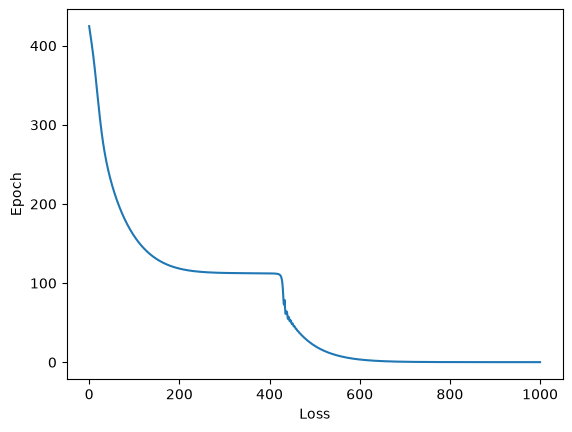

In [55]:
epochs = np.linspace(0, num_epochs, len(losses))
plt.plot(epochs, losses)
plt.xlabel("Loss")
plt.ylabel("Epoch")

# 7. Visualise output
not working

TypeError: Input z must be at least a (2, 2) shaped array, but has shape (30000, 1)

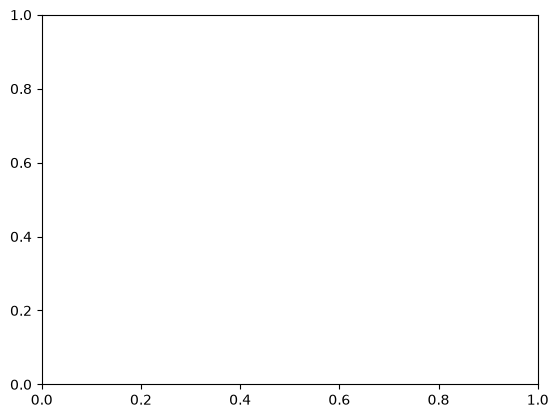

In [70]:
x = np.linspace(x_left, x_right, 300).reshape(-1, 1)
y = np.linspace(y_bot, y_top, 100).reshape(-1, 1)
x_mesh, y_mesh = np.meshgrid(x, y)
xy = np.hstack((x_mesh.reshape(-1, 1), y_mesh.reshape(-1, 1)))
with torch.no_grad():
    H_pre = model(torch.tensor(xy).float().to(device))

H_pre = H_pre.cpu().numpy()

fig, ax = plt.subplots()
contour = ax.contourf(x_mesh, y_mesh, H_pre, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(x_mesh, y_mesh, H_pre, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field (Adimensionalised)')
plt.show()